# Debug: LC08 path-002 December 2019 — why is the output mostly blank?

The mosaic `LC08_2-114_2-112_2-113_20191223_B4.tif` is only populated in the lower-left corner.
This notebook investigates each contributing scene individually:

1. STAC lookup — confirm scenes are found and print asset URLs  
2. GDAL probe — open each remote file and print CRS / bounds / nodata  
3. Individual downloads — download each scene separately and count valid pixels  
4. Footprint map — plot scene outlines and query bbox in EPSG:3031  
5. Raster panels — display each downloaded raster side-by-side

In [1]:
import logging
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from pyproj import Transformer
import rasterio
from osgeo import gdal

gdal.UseExceptions()
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')

from itslive_cloudfree.downloader import (
    _find_stac_item, _apply_cookie_config, _to_gdal_path, download_scene,
)
from itslive_cloudfree.results import SceneResult
from itslive_cloudfree.crs_utils import transform_bbox, bbox_to_wgs84

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
BBOX     = (-1_608_886, -286_925, -1_569_486, -251_379)  # (x0, y0, x1, y1) in EPSG:3031
BBOX_CRS = 3031
BBOX_WGS84 = bbox_to_wgs84(BBOX, BBOX_CRS)   # derived; used for footprint map / STAC geometry

DST_CRS  = 3031
OUT_DIR  = Path("debug_path002")
OUT_DIR.mkdir(exist_ok=True)

# Scenes in the December 2019 path-002 group
# scene_id, platform, path/row label
TARGETS = [
    ("LC08_L1GT_002114_20191223_20201016_02_T2", "LC08", "002/114"),
    ("LC08_L1GT_002112_20191223_20201016_02_T2", "LC08", "002/112"),
    ("LC08_L1GT_002113_20191223_20201016_02_T2", "LC08", "002/113"),
]

COLORS = ["#e41a1c", "#377eb8", "#4daf4a"]   # red, blue, green

print(f"BBOX (EPSG:{BBOX_CRS}): {BBOX}")
print(f"BBOX (WGS-84):         {tuple(f'{v:.4f}' for v in BBOX_WGS84)}")

BBOX (EPSG:3031): (-1608886, -286925, -1569486, -251379)
BBOX (WGS-84):         ('-100.3601', '-75.4465', '-98.8803', '-75.0409')


## 1 — STAC lookup

In [3]:
stac_items = {}

for scene_id, platform, pr in TARGETS:
    print(f"\n{'─'*60}")
    print(f"Scene  : {scene_id}")
    print(f"Path/row: {pr}")

    item = _find_stac_item(scene_id, platform)
    if item is None:
        print("  ✗  NOT FOUND in any STAC")
        continue

    stac_items[scene_id] = item
    print(f"  ✓  Found")
    print(f"  BBox (WGS-84) : {item.bbox}")

    red = item.assets.get("red")
    if red:
        print(f"  red href      : {red.href}")
    else:
        avail = list(item.assets.keys())
        print(f"  'red' asset missing — available: {avail}")


────────────────────────────────────────────────────────────
Scene  : LC08_L1GT_002114_20191223_20201016_02_T2
Path/row: 002/114
  ✓  Found
  BBox (WGS-84) : [-111.28600934125753, -77.10981509953079, -101.38616715385622, -74.68898168781226]
  red href      : https://landsatlook.usgs.gov/data/collection02/level-1/standard/oli-tirs/2019/002/114/LC08_L1GT_002114_20191223_20201016_02_T2/LC08_L1GT_002114_20191223_20201016_02_T2_B4.TIF

────────────────────────────────────────────────────────────
Scene  : LC08_L1GT_002112_20191223_20201016_02_T2
Path/row: 002/112
  ✓  Found
  BBox (WGS-84) : [-104.3971628954899, -74.65676688809015, -96.07549052142632, -72.2805867708126]
  red href      : https://landsatlook.usgs.gov/data/collection02/level-1/standard/oli-tirs/2019/002/112/LC08_L1GT_002112_20191223_20201016_02_T2/LC08_L1GT_002112_20191223_20201016_02_T2_B4.TIF

────────────────────────────────────────────────────────────
Scene  : LC08_L1GT_002113_20191223_20201016_02_T2
Path/row: 002/113
  ✓

## 2 — GDAL probe: open each remote file and inspect metadata

In [4]:
_apply_cookie_config()
gdal.SetConfigOption("AWS_NO_SIGN_REQUEST", "YES")
gdal.SetConfigOption("GDAL_DISABLE_READDIR_ON_OPEN", "EMPTY_DIR")
gdal.SetConfigOption("GDAL_HTTP_MAX_RETRY", "2")

bbox_native = transform_bbox(BBOX, BBOX_CRS, DST_CRS)
print(f"Query bbox in EPSG:{DST_CRS}: {tuple(int(v) for v in bbox_native)}\n")

for scene_id, platform, pr in TARGETS:
    item = stac_items.get(scene_id)
    if item is None:
        print(f"{pr}: skipped (no STAC item)\n")
        continue

    red = item.assets.get("red")
    if red is None:
        print(f"{pr}: no 'red' asset\n")
        continue

    href = _to_gdal_path(red.href)
    print(f"{pr}  →  {href[:90]}")

    ds = gdal.Open(href)
    if ds is None:
        print("  ✗  gdal.Open returned None (likely auth / network failure)\n")
        continue

    gt  = ds.GetGeoTransform()
    nd  = ds.GetRasterBand(1).GetNoDataValue()
    nx, ny = ds.RasterXSize, ds.RasterYSize
    x0, y0 = gt[0], gt[3]
    x1, y1 = x0 + nx * gt[1], y0 + ny * gt[5]
    wkt = ds.GetProjection()
    ds = None

    print(f"  Size      : {nx} × {ny} px  @  {gt[1]:.1f} m/px")
    print(f"  Bounds    : x [{x0:.0f}, {x1:.0f}]  y [{min(y0,y1):.0f}, {max(y0,y1):.0f}]")
    print(f"  Nodata    : {nd}")
    print(f"  CRS (trunc): {wkt[5:65]}")

    # Does this scene's native bbox intersect the query bbox?
    from pyproj import CRS
    from itslive_cloudfree.crs_utils import transform_bbox as tbbox
    scene_crs = CRS.from_wkt(wkt).to_epsg()
    if scene_crs:
        q = tbbox(BBOX, BBOX_CRS, scene_crs)
        intersects = (
            min(x0,x1) < q[2] and max(x0,x1) > q[0] and
            min(y0,y1) < q[3] and max(y0,y1) > q[1]
        )
        print(f"  Query bbox in scene CRS (EPSG:{scene_crs}): {tuple(int(v) for v in q)}")
        print(f"  Scene bbox intersects query bbox: {intersects}")
    print()

Query bbox in EPSG:3031: (-1608886, -286925, -1569486, -251379)

002/114  →  /vsicurl/https://landsatlook.usgs.gov/data/collection02/level-1/standard/oli-tirs/2019/002
  Size      : 8241 × 8311 px  @  30.0 m/px
  Bounds    : x [-1601415, -1354185]  y [-555315, -305985]
  Nodata    : 0.0
  CRS (trunc): S["PS         WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHERO
  Query bbox in scene CRS (EPSG:3031): (-1608886, -286925, -1569486, -251379)
  Scene bbox intersects query bbox: False

002/112  →  /vsicurl/https://landsatlook.usgs.gov/data/collection02/level-1/standard/oli-tirs/2019/002
  Size      : 8331 × 8391 px  @  30.0 m/px
  Bounds    : x [-1904415, -1654485]  y [-444315, -192585]
  Nodata    : 0.0
  CRS (trunc): S["PS         WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHERO
  Query bbox in scene CRS (EPSG:3031): (-1608886, -286925, -1569486, -251379)
  Scene bbox intersects query bbox: False

002/113  →  /vsicurl/https://landsatlook.usgs.gov/data/collection02/level-1/standard/oli-tirs/2

## 3 — Download each scene individually

In [5]:
download_paths = {}   # scene_id → Path or None

for scene_id, platform, pr in TARGETS:
    sr = SceneResult(
        scene_id=scene_id,
        platform=platform,
        acquisition_date=datetime(2019, 12, 23, tzinfo=timezone.utc),
        path_row=pr,
        tile=None,
        pair_count=0,
        mean_valid_pixels=0.0,
        cloud_free_score=0.0,
    )

    print(f"Downloading {pr} ({scene_id}) ...")
    try:
        result = download_scene(
            sr, bbox=BBOX, bbox_crs=BBOX_CRS,
            bands=["red"], out_dir=OUT_DIR, skip_existing=False,
        )
        p = result.get("red")
        if p and p.exists():
            with rasterio.open(p) as src:
                data   = src.read(1).astype(float)
                nd_val = src.nodata if src.nodata is not None else 0
            valid = data != nd_val
            download_paths[scene_id] = p
            print(f"  Saved to {p.name}")
            print(f"  Size : {data.shape[1]} × {data.shape[0]} px")
            print(f"  Valid: {valid.sum():,} / {valid.size:,} = {100*valid.mean():.1f}%")
        else:
            print("  No output file produced")
    except Exception as exc:
        print(f"  FAILED: {exc}")
    print()

INFO itslive_cloudfree.downloader: Downloading LC08_L1GT_002114_20191223_20201016_02_T2 band red → debug_path002/LC08_L1GT_002114_20191223_20201016_02_T2_B4.tif


  FAILED: Intersection is empty Window(col_off=np.float64(-249.03333333333333), row_off=np.float64(-1820.2), width=np.float64(1313.3333333333333), height=np.float64(1184.8666666666668)) Window(col_off=0, row_off=0, width=8241, height=8311)



INFO itslive_cloudfree.downloader: Downloading LC08_L1GT_002112_20191223_20201016_02_T2 band red → debug_path002/LC08_L1GT_002112_20191223_20201016_02_T2_B4.tif


  FAILED: Intersection is empty Window(col_off=np.float64(9850.966666666667), row_off=np.float64(1959.8), width=np.float64(1313.3333333333321), height=np.float64(1184.8666666666666)) Window(col_off=0, row_off=0, width=8331, height=8391)



INFO itslive_cloudfree.downloader: Downloading LC08_L1GT_002113_20191223_20201016_02_T2 band red → debug_path002/LC08_L1GT_002113_20191223_20201016_02_T2_B4.tif


  Saved to LC08_L1GT_002113_20191223_20201016_02_T2_B4.tif
  Size : 1313 × 1185 px
  Valid: 108,427 / 1,555,905 = 7.0%



## 4 — Footprint map: scene outlines vs query bbox

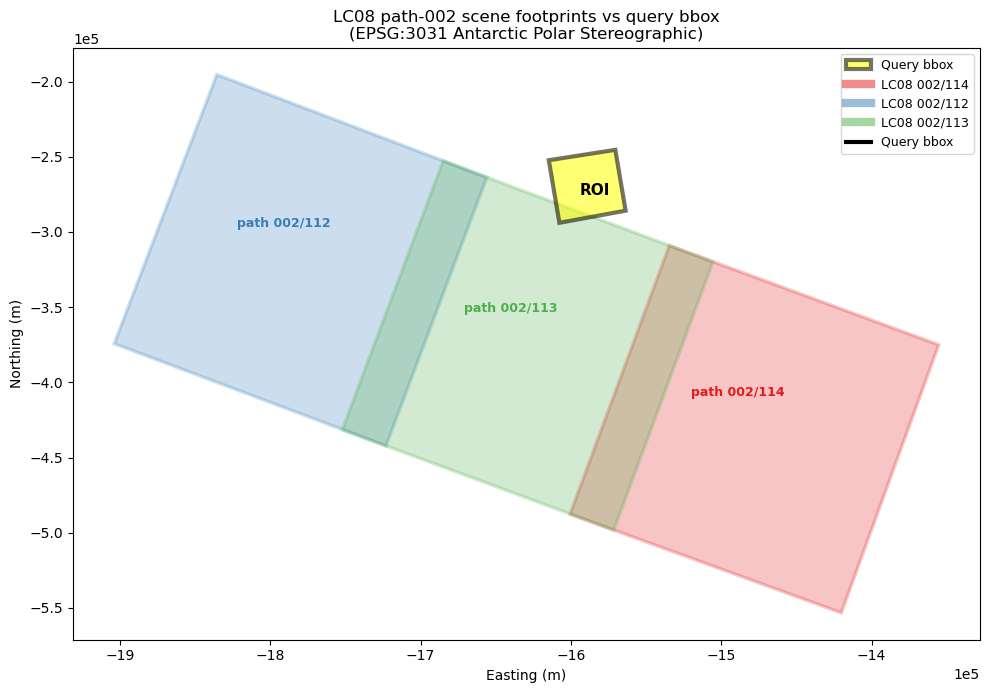

In [6]:
t = Transformer.from_crs("EPSG:4326", f"EPSG:{DST_CRS}", always_xy=True)

def wgs84_ring_to_proj(ring):
    """GeoJSON coordinate ring [[lon,lat],...] → projected (xs, ys)."""
    lons = [c[0] for c in ring]
    lats = [c[1] for c in ring]
    return t.transform(lons, lats)

# bbox corners
lon0, lat0, lon1, lat1 = BBOX_WGS84
bbox_ring = [[lon0,lat0],[lon1,lat0],[lon1,lat1],[lon0,lat1],[lon0,lat0]]
bx, by = wgs84_ring_to_proj(bbox_ring)

fig, ax = plt.subplots(figsize=(10, 9))

patches, labels = [], []
for (scene_id, platform, pr), color in zip(TARGETS, COLORS):
    item = stac_items.get(scene_id)
    if item is None:
        continue
    geom = item.geometry
    if not geom or geom.get("type") != "Polygon":
        continue
    ring = geom["coordinates"][0]
    xs, ys = wgs84_ring_to_proj(ring)
    poly = MplPolygon(
        list(zip(xs, ys)), closed=True,
        facecolor=color, edgecolor=color, alpha=0.25, linewidth=2.5,
    )
    ax.add_patch(poly)
    # label at centroid
    cx, cy = np.mean(xs), np.mean(ys)
    ax.text(cx, cy, f"path {pr}", ha="center", va="center",
            fontsize=9, color=color, fontweight="bold")

# query bbox — draw last so it's on top
bbox_poly = MplPolygon(
    list(zip(bx, by)), closed=True,
    facecolor="yellow", edgecolor="black", alpha=0.55, linewidth=3,
    label="Query bbox",
)
ax.add_patch(bbox_poly)
ax.text(np.mean(bx), np.mean(by), "ROI", ha="center", va="center",
        fontsize=11, fontweight="bold", color="black")

# legend proxies
for (scene_id, _, pr), color in zip(TARGETS, COLORS):
    ax.plot([], [], color=color, linewidth=6, alpha=0.5, label=f"LC08 {pr}")
ax.plot([], [], color="black", linewidth=3, label="Query bbox")

ax.autoscale_view()
ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=9)
ax.set_title(
    "LC08 path-002 scene footprints vs query bbox\n"
    "(EPSG:3031 Antarctic Polar Stereographic)",
    fontsize=12,
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="sci", axis="both", scilimits=(5,5))
plt.tight_layout()
plt.savefig(OUT_DIR / "footprints.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 — Individual raster panels

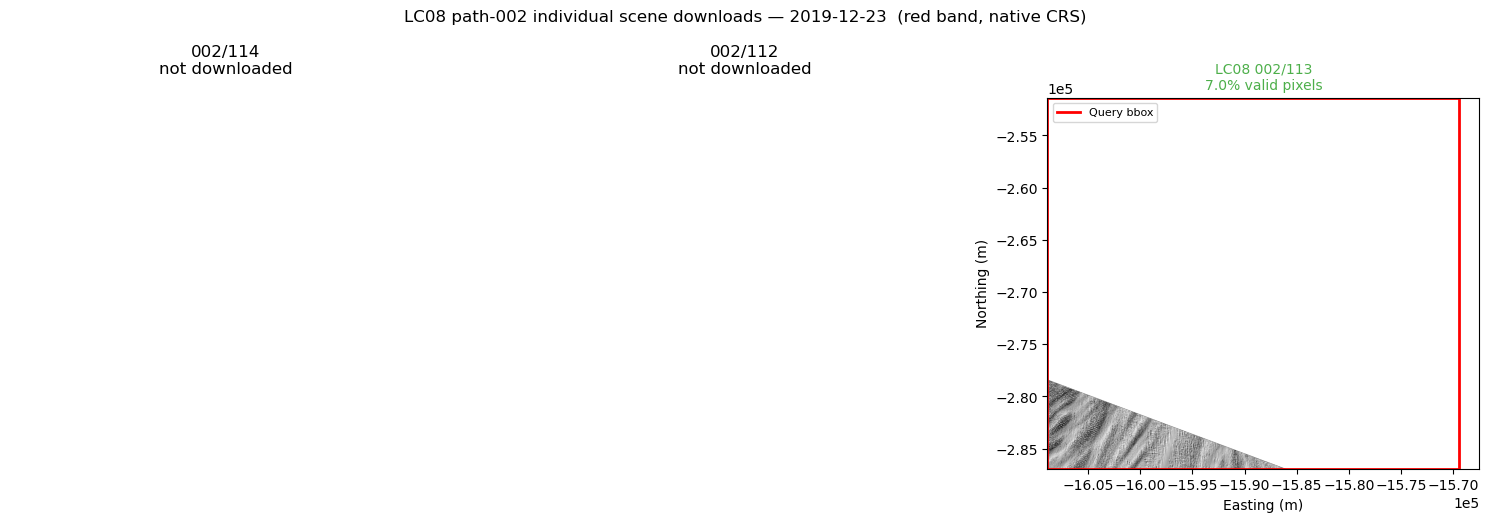

In [7]:
fig, axes = plt.subplots(1, len(TARGETS), figsize=(15, 5))

for ax, (scene_id, platform, pr), color in zip(axes, TARGETS, COLORS):
    p = download_paths.get(scene_id)
    if p is None or not p.exists():
        ax.set_title(f"{pr}\nnot downloaded")
        ax.axis("off")
        continue

    with rasterio.open(p) as src:
        data   = src.read(1).astype(float)
        nd_val = src.nodata if src.nodata is not None else 0
        bounds = src.bounds
        scene_epsg = src.crs.to_epsg()

    valid   = data != nd_val
    display = np.where(valid, data, np.nan)

    if valid.any():
        lo, hi = np.nanpercentile(display[valid], [2, 98])
    else:
        lo, hi = 0, 1

    ax.imshow(
        display, vmin=lo, vmax=hi, cmap="gray", origin="upper",
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    )

    # overlay bbox outline in the scene's native CRS
    if scene_epsg:
        q = transform_bbox(BBOX, BBOX_CRS, scene_epsg)
        rect_x = [q[0], q[2], q[2], q[0], q[0]]
        rect_y = [q[1], q[1], q[3], q[3], q[1]]
        ax.plot(rect_x, rect_y, "r-", linewidth=2, label="Query bbox")
        ax.legend(fontsize=8)

    ax.set_title(
        f"LC08 {pr}\n{100*valid.mean():.1f}% valid pixels",
        color=color, fontsize=10,
    )
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.ticklabel_format(style="sci", axis="both", scilimits=(5,5))

plt.suptitle(
    "LC08 path-002 individual scene downloads — 2019-12-23  (red band, native CRS)",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "individual_scenes.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 — Why does the scorer give path 002 high coverage?

For each ItsLive pair that involves a path-002 scene we:
1. Check whether it is a **cross-path pair** (path 002 ↔ different path) — those are now skipped by the scorer.
2. For **within-path pairs** (002 ↔ 002), fetch `chip_size_height` at the bbox and report the coverage fraction actually attributed to path 002.

This reveals whether the high score comes from cross-path pairs leaking through the filter,
or from within-path pairs that happen to cover the bbox.

In [8]:
from itslive_cloudfree.stac_client import search_granules
from itslive_cloudfree.coverage import (
    _snap_bbox, _fetch_pair_coverage, _wrs_path_number, _get_data_url,
    _GRID_SPACING,
)

# Snapped bbox used by the scorer
bbox_snapped = _snap_bbox(BBOX)   # BBOX is already in EPSG:3031
x0s, y0s, x1s, y1s = bbox_snapped
n_cols = round((x1s - x0s) / _GRID_SPACING) + 1
n_rows = round((y1s - y0s) / _GRID_SPACING) + 1
print(f"Scorer snapped bbox : {bbox_snapped}")
print(f"Scorer grid         : {n_rows} rows × {n_cols} cols\n")

# Fetch ItsLive pairs for a broader window around December 2019
print("Fetching ItsLive granules (2019-09-01 – 2020-03-31) …")
granules = list(search_granules(
    bbox=BBOX_WGS84,
    start_date="2019-09-01",
    end_date="2020-03-31",
    max_items=1000,
))
print(f"Total granules: {len(granules)}\n")

# ── Filter to pairs that involve at least one path-002 scene ──────────────
PATH002_PREFIX = ("LC08_L1GT_002", "LC08_L1TP_002",
                  "LC09_L1GT_002", "LC09_L1TP_002")

def has_path002(sid):
    return sid and any(sid.startswith(p) for p in PATH002_PREFIX)

path002_pairs = [
    item for item in granules
    if has_path002(item["properties"].get("scene_1_id") or item["properties"].get("scene_1_frame"))
    or has_path002(item["properties"].get("scene_2_id") or item["properties"].get("scene_2_frame"))
]
print(f"Pairs involving path 002: {len(path002_pairs)}\n")

# ── For each pair: classify and optionally fetch coverage ─────────────────
accumulated: dict[str, np.ndarray] = {}   # scene_id → cumulative OR grid

for item in path002_pairs:
    props = item["properties"]
    s1 = props.get("scene_1_id") or props.get("scene_1_frame", "")
    s2 = props.get("scene_2_id") or props.get("scene_2_frame", "")
    p1 = _wrs_path_number(s1) if s1 else None
    p2 = _wrs_path_number(s2) if s2 else None
    is_cross = bool(p1 and p2 and p1 != p2)

    url = _get_data_url(item)

    if is_cross:
        # Show what coverage this pair would have contributed WITHOUT the filter
        pair_cov = _fetch_pair_coverage(url, bbox_snapped) if url else None
        frac = pair_cov.mean() if pair_cov is not None else None
        tag = f"CROSS-PATH {p1}↔{p2}"
        frac_str = f"{frac:.1%}" if frac is not None else "no data"
        print(f"  [SKIP] {s1[-32:]:32s} ↔ {s2[-32:]:32s}  {tag}  (would have been {frac_str})")
    else:
        pair_cov = _fetch_pair_coverage(url, bbox_snapped) if url else None
        if pair_cov is not None:
            frac = pair_cov.mean()
            for sid in (s1, s2):
                if not sid:
                    continue
                if sid not in accumulated:
                    accumulated[sid] = pair_cov.copy()
                else:
                    np.logical_or(accumulated[sid], pair_cov, out=accumulated[sid])
        else:
            frac = None
        frac_str = f"{frac:.1%}" if frac is not None else "no data"
        print(f"  [USE ] {s1[-32:]:32s} ↔ {s2[-32:]:32s}  within-path {p1}  coverage={frac_str}")

print(f"\n{'─'*70}")
print("Per-scene accumulated coverage after cross-path filter:")
for sid, grid in accumulated.items():
    print(f"  {sid[-40:]:40s}  {grid.mean():.1%}")

Scorer snapped bbox : (-1608900.0, -286980.0, -1569540.0, -251340.0)
Scorer grid         : 298 rows × 329 cols

Fetching ItsLive granules (2019-09-01 – 2020-03-31) …
Total granules: 205

Pairs involving path 002: 18

  [USE ] T_002112_20200108_20201016_02_T2 ↔ T_002112_20200124_20201016_02_T2  within-path 002  coverage=100.0%
  [USE ] T_002113_20191223_20201016_02_T2 ↔ T_002113_20200124_20201016_02_T2  within-path 002  coverage=7.0%
  [USE ] T_002113_20191223_20201016_02_T2 ↔ T_002113_20200108_20201016_02_T2  within-path 002  coverage=7.0%
  [USE ] T_002112_20191223_20201016_02_T2 ↔ T_002112_20200124_20201016_02_T2  within-path 002  coverage=100.0%
  [USE ] T_002112_20191223_20201016_02_T2 ↔ T_002112_20200108_20201016_02_T2  within-path 002  coverage=100.0%
  [USE ] T_002113_20191207_20201016_02_T2 ↔ T_002113_20200124_20201016_02_T2  within-path 002  coverage=61.8%
  [USE ] T_002113_20191207_20201016_02_T2 ↔ T_002113_20200108_20201016_02_T2  within-path 002  coverage=61.8%
  [USE ] T_0

In [9]:
import fsspec
import h5py

# Pick the first 002/112 pair that showed 100% coverage
probe_item = next(
    item for item in path002_pairs
    if "002112" in (item["properties"].get("scene_1_id", "") or "")
    and item["properties"].get("scene_1_id", "")[-32:].startswith("T_002112")
        == item["properties"].get("scene_2_id", "")[-32:].startswith("T_002112")
)
# Simpler: just take the first 002/112 pair
probe_item = next(
    item for item in path002_pairs
    if "002112" in (item["properties"].get("scene_1_id") or "")
)

probe_url = _get_data_url(probe_item)
props = probe_item["properties"]
print(f"Pair STAC bbox (WGS-84) : {probe_item.get('bbox')}")
print(f"scene_1 : {props.get('scene_1_id')}")
print(f"scene_2 : {props.get('scene_2_id')}")
print(f"URL     : {probe_url}\n")

# Open the NetCDF and inspect x/y extent
of = fsspec.open(probe_url, "rb")
with of as f, h5py.File(f, "r") as ds:
    x = ds["x"][:]
    y = ds["y"][:]
    csh = ds["chip_size_height"]
    print(f"NetCDF x range : [{x.min():.0f}, {x.max():.0f}]  n={len(x)}")
    print(f"NetCDF y range : [{y.min():.0f}, {y.max():.0f}]  n={len(y)}")
    print(f"chip_size_height shape: {csh.shape}  dtype: {csh.dtype}")
    print()

    # Where does the bbox fall in the grid?
    x0b, y0b, x1b, y1b = bbox_snapped
    xi0 = int(np.searchsorted(x, x0b, side="left"))
    xi1 = int(np.searchsorted(x, x1b, side="right"))
    if len(y) > 1 and float(y[0]) > float(y[-1]):
        yi0 = int(np.searchsorted(-y, -y1b, side="left"))
        yi1 = int(np.searchsorted(-y, -y0b, side="right"))
    else:
        yi0 = int(np.searchsorted(y, y0b, side="left"))
        yi1 = int(np.searchsorted(y, y1b, side="right"))

    print(f"Bbox maps to x indices [{xi0}, {xi1}] (of 0..{len(x)-1})")
    print(f"Bbox maps to y indices [{yi0}, {yi1}] (of 0..{len(y)-1})")

    if xi0 < xi1 and yi0 < yi1:
        if csh.ndim == 3:
            window = csh[0, yi0:yi1, xi0:xi1]
        else:
            window = csh[yi0:yi1, xi0:xi1]
        window = np.asarray(window)
        print(f"\nchip_size_height window shape : {window.shape}")
        print(f"  non-zero cells : {(window > 0).sum()} / {window.size} = {(window > 0).mean():.1%}")
        print(f"  value counts   : {dict(zip(*np.unique(window[:5,:5], return_counts=True)))}")
    else:
        print("Bbox slice is empty — granule does NOT cover the bbox in x/y")

Pair STAC bbox (WGS-84) : [-105.0682, -75.2784, -95.5273, -72.1685]
scene_1 : LC08_L1GT_002112_20200108_20201016_02_T2
scene_2 : LC08_L1GT_002112_20200124_20201016_02_T2
URL     : https://its-live-data.s3.amazonaws.com/velocity_image_pair/landsatOLI/v02/S70W090/LC08_L1GT_002112_20200108_20201016_02_T2_X_LC08_L1GT_002112_20200124_20201016_02_T2_G0120V02_P080.nc

NetCDF x range : [-1904588, -1597508]  n=2560
NetCDF y range : [-430012, -184372]  n=2048
chip_size_height shape: (1, 2048, 2560)  dtype: uint16

Bbox maps to x indices [2465, 2560] (of 0..2559)
Bbox maps to y indices [559, 856] (of 0..2047)

chip_size_height window shape : (297, 95)
  non-zero cells : 28215 / 28215 = 100.0%
  value counts   : {np.uint16(32769): np.int64(25)}


In [10]:
# Confirm fill value and chip_size_height encoding
of = fsspec.open(probe_url, "rb")
with of as f, h5py.File(f, "r") as ds:
    var = ds["chip_size_height"]
    print("_FillValue attr  :", var.attrs.get("_FillValue"))
    print("h5py fillvalue   :", var.fillvalue)
    print("units            :", var.attrs.get("units"))
    print("y_pixel_size (m) :", var.attrs.get("y_pixel_size"))
    print()
    print("Value at bbox edge: 32769 = 0x8001 (bit 15 set)")
    print("ItsLive convention: bit 15 set = interpolated/outside scene boundary")
    print()
    print("Classification check (new fix: 0 < chip < 0x8000):")
    for v in [0, 120, 960, 3840, 32768, 32769, 65535]:
        chip = np.uint16(v)
        valid = bool((chip > 0) & (chip < np.uint16(0x8000)))
        print(f"  chip={v:6d} (0x{v:04X})  valid={valid}")


_FillValue attr  : 0
h5py fillvalue   : 0
units            : m
y_pixel_size (m) : 15.0

Value at bbox edge: 32769 = 0x8001 (bit 15 set)
ItsLive convention: bit 15 set = interpolated/outside scene boundary

Classification check (new fix: 0 < chip < 0x8000):
  chip=     0 (0x0000)  valid=False
  chip=   120 (0x0078)  valid=True
  chip=   960 (0x03C0)  valid=True
  chip=  3840 (0x0F00)  valid=True
  chip= 32768 (0x8000)  valid=False
  chip= 32769 (0x8001)  valid=False
  chip= 65535 (0xFFFF)  valid=False
